## Exploratory Data Analysis to Support Housing Price Research

**Author**: Baher Alabbar  
**Date**: February 2025  


### Objective of the EDA 

This notebook aims to conduct a thorough exploratory data analysis (EDA) on the House Price dataset with the following goals:

1. Examine individual features and their relationships with the target variable.
2. Assess data quality by identifying missing values, noisy features, and variables that may require transformation or removal.
3. Identify opportunities for meaningful feature engineering to improve predictive performance.
4. Generate insights that inform model selection and evaluation.

---

### Target Variable

The target variable is `SalePrice`, measured in U.S. dollars. Due to its right-skewed distribution, we primarily work with its `log1p` transformation, denoted as `log_sale_price`. Applying `log1p` reduces the influence of extreme values and helps stabilize variance, which can improve model performance. Model predictions are generated in the log-transformed space and subsequently transformed back to the original dollar scale using the inverse transformation (`expm1`) for interpretation and evaluation.

---
### EDA Structure

Below is an outline of the EDA sections to guide navigation and ensure coverage of key areas.

<details>
<summary><strong>Click to expand the EDA Sections</strong></summary>

- [Load and Inspect the Data](#load-and-inspect-the-data)  
  Load the dataset, check its shape, structure, and basic statistics.

- [1. Dataset Feature Descriptions](#1-columns-and-descriptions)  
  Explanation of each feature in the dataset.

- [2. Data Cleaning and Preprocessing](#2-data-cleaning-and-preprocessing)  
  Initial feature selection, then handle missing values, fix data types, and prepare for analysis.

- [3. Outlier Detection and Target Variable Transformation](#3-outlier-detection-and-target-variable-transformation)  
  Visualize and understand outliers and whether log1p is needed.

- [4. Categorical Feature Analysis](#4-categorical-feature-analysis)   
  Analyze categorical features and their effect on sale prices.

- [5. Numerical Feature Analysis](#5-numerical-feature-analysis)   
  Analyze numerical features and their effect on sale prices.

- [6. Domain-Specific Feature Analysis](#6-domain-specific-feature-analysis)
  Examine how housing-related features such as neighborhood, zoning, lot characteristics, and structural attributes influence sale prices.

- [7. Domain-Specific Temporal Feature Analysis](#7-domain-specific-temporal-feature-analysis)
  Analyze how time-related features, including year built, year remodeled, month sold, and year sold, affect housing prices.

- [8. Relationships Between Features](#8-relationships-between-features)  
  Examine how features interact or correlate with one another.

- [9. Feature Engineering](#9-feature-engineering)  
  Create, evaluate, and justify new features that may improve the model.

- [10. Summary and Next Steps](#10-summary-and-next-steps)  
  Wrap up findings, hypotheses, and prepare for modeling.

- [Acknowledgments](#acknowledgments)

</details>

### Load and Inspect The Data

In [347]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [348]:
pd.options.display.max_columns = None  # Show all columns
pd.options.display.max_rows = 500

import warnings

# ignore FutureWarnings and UserWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [349]:
df = pd.read_csv("../data/split/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,Wd Sdng,NaN,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


In [350]:
df.select_dtypes("number").describe().T 

,count,mean,std,min,25%,50%,75%,max
Id,1168.0,730.904966,425.369088,1.0,360.75,732.5,1101.75,1460.0
MSSubClass,1168.0,56.849315,42.531862,20.0,20.00,50.0,70.00,190.0
LotFrontage,951.0,70.343849,24.897021,21.0,59.00,70.0,80.00,313.0
LotArea,1168.0,10689.642123,10759.366198,1300.0,7587.25,9600.0,11700.00,215245.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
OverallCond,1168.0,5.584760,1.116062,1.0,5.00,5.0,6.00,9.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0
YearRemodAdd,1168.0,1984.897260,20.733955,1950.0,1966.00,1994.0,2004.00,2010.0
MasVnrArea,1162.0,103.771945,173.032238,0.0,0.00,0.0,166.00,1378.0
BsmtFinSF1,1168.0,446.023973,459.070977,0.0,0.00,384.5,721.00,5644.0


In [351]:
df.select_dtypes("object").describe().T

,count,unique,top,freq
MSZoning,1168,5,RL,924
Street,1168,2,Pave,1164
Alley,74,2,Grvl,44
LotShape,1168,4,Reg,729
LandContour,1168,4,Lvl,1059
Utilities,1168,2,AllPub,1167
LotConfig,1168,5,Inside,822
LandSlope,1168,3,Gtl,1108
Neighborhood,1168,25,NAmes,181
Condition1,1168,9,Norm,1004


In [352]:
print(df.shape)
print("Categorical:", df.select_dtypes("object").shape)  # categorical 
print("Numerical:",df.select_dtypes("number").shape)  # numerical

(1168, 81)
Categorical: (1168, 43)
Numerical: (1168, 38)


It is clear that the dataset is high-dimensional, containing 81 features, making a detailed investigation of every variable impractical. Therefore, an initial feature screening step is necessary to reduce the features amount and focus the analysis on variables that are most relevant and informative for further investigation.

### 1. Columns and Descriptions

In [353]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

#### Feature Overview (Grouped Summary)

**Identifiers & Target**
- **Id**: Unique identifier for each property.
- **SalePrice**: Final sale price of the house (target variable).

**Property Type & Zoning**
- **MSSubClass**: Dwelling type and style category.
- **MSZoning**: General zoning classification of the property.
- **BldgType**: Type of building structure (e.g., single-family, townhouse).
- **HouseStyle**: Architectural style of the house.

**Lot & Land Characteristics**
- **LotFrontage**: Linear feet of street connected to the property.
- **LotArea**: Total lot size in square feet.
- **LotShape**: Shape regularity of the lot.
- **LandContour**: Flatness or slope of the land.
- **LotConfig**: Lot position and configuration.
- **LandSlope**: Slope steepness of the property.
- **Street**: Type of road access.
- **Alley**: Type of alley access, if any.
- **Utilities**: Available utilities for the property.

**Location & Neighborhood**
- **Neighborhood**: Physical neighborhood within Ames city limits.
- **Condition1**: Proximity to roads, railroads, or amenities.
- **Condition2**: Secondary proximity condition, if applicable.

**Overall Quality & Condition**
- **OverallQual**: Overall material and finish quality.
- **OverallCond**: Overall condition of the house.

**Construction & Renovation**
- **YearBuilt**: Original construction year.
- **YearRemodAdd**: Year of last remodel or addition.
- **RoofStyle**: Roof shape or design.
- **RoofMatl**: Roof material.
- **Foundation**: Foundation type.

**Exterior Features**
- **Exterior1st**: Primary exterior covering material.
- **Exterior2nd**: Secondary exterior covering material.
- **MasVnrType**: Masonry veneer type.
- **MasVnrArea**: Masonry veneer area in square feet.
- **ExterQual**: Exterior material quality.
- **ExterCond**: Exterior material condition.

**Basement Features**
- **BsmtQual**: Basement height quality.
- **BsmtCond**: Basement condition.
- **BsmtExposure**: Walkout or garden-level exposure.
- **BsmtFinType1**: Quality of main finished basement area.
- **BsmtFinSF1**: Finished basement square feet (type 1).
- **BsmtFinType2**: Quality of secondary finished basement area.
- **BsmtFinSF2**: Finished basement square feet (type 2).
- **BsmtUnfSF**: Unfinished basement area.
- **TotalBsmtSF**: Total basement area.
- **BsmtFullBath**: Basement full bathrooms.
- **BsmtHalfBath**: Basement half bathrooms.

**Heating, Cooling & Utilities**
- **Heating**: Heating system type.
- **HeatingQC**: Heating quality and condition.
- **CentralAir**: Presence of central air conditioning.
- **Electrical**: Electrical system type.

**Living Area & Room Counts**
- **1stFlrSF**: First-floor living area.
- **2ndFlrSF**: Second-floor living area.
- **LowQualFinSF**: Low-quality finished living area.
- **GrLivArea**: Total above-ground living area.
- **FullBath**: Full bathrooms above grade.
- **HalfBath**: Half bathrooms above grade.
- **BedroomAbvGr**: Bedrooms above grade.
- **KitchenAbvGr**: Kitchens above grade.
- **KitchenQual**: Kitchen quality.
- **TotRmsAbvGrd**: Total rooms above grade (excluding bathrooms).
- **Functional**: Overall home functionality rating.
- **Fireplaces**: Number of fireplaces.
- **FireplaceQu**: Fireplace quality.

**Garage Features**
- **GarageType**: Garage location/type.
- **GarageYrBlt**: Garage construction year.
- **GarageFinish**: Garage interior finish.
- **GarageCars**: Garage capacity (number of cars).
- **GarageArea**: Garage size in square feet.
- **GarageQual**: Garage quality.
- **GarageCond**: Garage condition.
- **PavedDrive**: Driveway paving type.

**Porch, Deck & Outdoor Amenities**
- **WoodDeckSF**: Wood deck area.
- **OpenPorchSF**: Open porch area.
- **EnclosedPorch**: Enclosed porch area.
- **3SsnPorch**: Three-season porch area.
- **ScreenPorch**: Screen porch area.
- **PoolArea**: Pool area in square feet.
- **PoolQC**: Pool quality.
- **Fence**: Fence quality.
- **MiscFeature**: Miscellaneous features not covered elsewhere.
- **MiscVal**: Value of miscellaneous features.

**Sale Information**
- **MoSold**: Month of sale.
- **YrSold**: Year of sale.
- **SaleType**: Type of sale transaction.
- **SaleCondition**: Condition under which the sale occurred.

*This summary is inspired by the official feature descriptions provided with the dataset.*

### 2. Data Cleaning and Preprocessing

#### 2.1 Feature Filtering Strategy

Since the dataset contains around 80 features, inspecting each one in detail would be inefficient and unnecessarily complex. As an initial dimensionality reduction step, I will remove less informative variables and retain those that are more likely to influence `SalePrice`.  

The column reduction will follow this methodology:  

1. **High Missingness Removal**  
   Drop variables with a large proportion of missing values.

2. **Redundancy Elimination**  
   Remove columns that have very similar meaning or capture overlapping information.

3. **Irrelevant / Identifier Exclusion**  
   Exclude identifier variables or features that are clearly unrelated to price.

4. **Low-Variance Filtering**  
   Remove features where one value is repeated for the majority of observations and only a small number differ. These variables provide very limited predictive information.

5. **Leakage Prevention**  
   Exclude variables that cannot realistically be obtained at prediction time, are typically only available after the sale process, or are impractical to inspect. This ensures the model reflects a realistic prediction setting.  

6. **Lasso-Based Feature Selection**  
   Apply Lasso (L1-regularized regression) to shrink less important coefficients toward zero. This allows the model to automatically remove weaker predictors and retain only the most relevant variables in a systematic and interpretable way.

7. **Tree-Based Feature Importance**  
   Use tree-based model (Random Forest) to evaluate feature importance and identify variables that contribute most to predictive performance. Unlike simple correlation analysis, tree-based methods can capture nonlinear relationships and interaction effects between variables, providing a more flexible assessment of feature relevance.

This step simplifies the analysis, reduces noise, and makes the modeling process more efficient and interpretable.


In [354]:
# 1. High Missingness Removal

# Count missing values per column and sort from highest to lowest
missing_counts = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

print(missing_counts.head(10))

PoolQC         1162
MiscFeature    1122
Alley          1094
Fence           935
MasVnrType      683
FireplaceQu     547
LotFrontage     217
GarageYrBlt      64
GarageCond       64
GarageType       64
dtype: int64


Since the dataset contains 1,168 observations, I will remove any column with missing values close to 50% of the data. Based on the missing-value counts, this corresponds to dropping the top six columns with the highest proportion of missing entries. The remaining variables will be retained, and appropriate imputation methods may be applied in later preprocessing steps.

In [355]:
cols_to_drop = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'MasVnrType',
    'FireplaceQu',
]

df = df.drop(columns=cols_to_drop)

print("Dropped columns:")
print(cols_to_drop)
print("New shape:", df.shape)

Dropped columns:
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
New shape: (1168, 75)


In [356]:
# 2. Redundancy Elimination

redundant_cols_to_drop = [
    "Exterior2nd",
    "Condition2",
    "GarageArea",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
]

df = df.drop(columns=redundant_cols_to_drop)

print("Dropped redundant columns:", redundant_cols_to_drop)
print("New shape:", df.shape)


Dropped redundant columns: ['Exterior2nd', 'Condition2', 'GarageArea', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
New shape: (1168, 66)


The following columns are removed because they repeat information that is already captured by other variables in the dataset. Keeping both the detailed parts and their overall totals would add unnecessary repetition without improving the analysis.

- **Exterior2nd** is often very similar to `Exterior1st` and usually does not add much new information.  
- **Condition2** frequently repeats what is already described in `Condition1`.  
- **GarageArea** measures garage size, which is already reflected by `GarageCars`.  
- **1stFlrSF**, **2ndFlrSF**, and **LowQualFinSF** together make up `GrLivArea`, which already represents total above-ground living space.  
- **BsmtFinSF1**, **BsmtFinSF2**, and **BsmtUnfSF** together make up `TotalBsmtSF`, which already represents total basement area.

By keeping the overall summary variables (such as `GrLivArea` and `TotalBsmtSF`) instead of their individual components, the dataset becomes simpler and easier to work with while avoiding repeated information.


In [357]:
# 3. Irrelevant / Identifier Exclusion

# Id is a unique identifier and does not provide information.

df = df.drop(columns=["Id"])

print("New shape:", df.shape)


New shape: (1168, 65)


In [358]:
# 4. Low-Variance Inspection for Categorical Features

categorical_cols = df.select_dtypes(include="object").columns

summary = []

for col in categorical_cols:
    vc = df[col].value_counts()
    summary.append({
        "Column": col,
        "Unique_Values": df[col].nunique(),
        "Top_Value": vc.index[0],
        "Top_Count": vc.iloc[0],
        "Top_Percentage": vc.iloc[0] / len(df)
    })

summary_df = pd.DataFrame(summary)

# Sort by percentage
summary_df = summary_df.sort_values(by="Top_Percentage", ascending=False)

print(summary_df)

           Column  Unique_Values Top_Value  Top_Count  Top_Percentage
4       Utilities              2    AllPub       1167        0.999144
1          Street              2      Pave       1164        0.996575
12       RoofMatl              7   CompShg       1149        0.983733
22        Heating              6      GasA       1140        0.976027
6       LandSlope              3       Gtl       1108        0.948630
24     CentralAir              2         Y       1085        0.928938
27     Functional              7       Typ       1084        0.928082
25     Electrical              4     SBrkr       1071        0.916952
32     PavedDrive              3         Y       1070        0.916096
31     GarageCond              5        TA       1061        0.908390
3     LandContour              4       Lvl       1059        0.906678
30     GarageQual              5        TA       1050        0.898973
18       BsmtCond              4        TA       1045        0.894692
15      ExterCond   

In [359]:
# Threshold for dropping
threshold = 0.90

categorical_cols = df.select_dtypes(include="object").columns
low_variance_cols = []

for col in categorical_cols:
    top_percentage = df[col].value_counts(normalize=True).iloc[0]
    if top_percentage >= threshold:
        low_variance_cols.append(col)

# Drop them
df = df.drop(columns=low_variance_cols)

print("Dropped low-variance categorical columns:", low_variance_cols)
print("New shape:", df.shape)


Dropped low-variance categorical columns: ['Street', 'LandContour', 'Utilities', 'LandSlope', 'RoofMatl', 'BsmtCond', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageQual', 'GarageCond', 'PavedDrive']
New shape: (1168, 52)


In [360]:
# 5. Leakage prevention

leakage_cols = [
    "SaleType",
    "SaleCondition",
    "MoSold",
    "YrSold"
]

leakage_cols = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=leakage_cols)

print("Dropped leakage-related columns:", leakage_cols)
print("New shape:", df.shape)

Dropped leakage-related columns: ['SaleType', 'SaleCondition', 'MoSold', 'YrSold']
New shape: (1168, 48)


The following variables are removed because they reflect transaction-level
information that would not be available when predicting price prior to sale.

- **SaleType** and **SaleCondition** describe the nature and outcome of the transaction.
- **MoSold** and **YrSold** represent timing of the sale rather than structural property characteristics.

Removing these ensures that the model relies only on features that describe
the property itself and would realistically be available at prediction time.

In [361]:
# 6. Lasso-Based Feature Selection

# More about this technique: (StatQuest)
# https://www.youtube.com/watch?v=NGf0voTMlcs
# We are relying on the fact that Lasso uses absolute value which causes the non important features to
# converge to 0 as the error gets minimized

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Pipeline: impute → scale → lasso
# (we need to scale before using lasso to ensure it can reduce non important features to 0) 
# We also impute because the lasso does not work on NAN values
lasso_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, n_alphas=200, max_iter=10000))
])

lasso_pipe.fit(X_train, y_train)

# Extract selected features
lasso_model = lasso_pipe.named_steps["lasso"]
coefs = pd.Series(lasso_model.coef_, index=X_train.columns)

selected = coefs[coefs != 0].sort_values(key=np.abs, ascending=False)

# Selected encoded feature names
selected_encoded_features = selected.index.tolist()

# Get original feature names (before encoding)
original_features = X.columns.tolist()

# Map encoded names back to original columns
selected_original_features = set()

for feature in selected_encoded_features:
    for col in original_features:
        if feature.startswith(col + "_") or feature == col:
            selected_original_features.add(col)

# Columns to drop from original df
cols_to_drop = [col for col in original_features if col not in selected_original_features]

print("Number of original features:", len(original_features))
print("Selected original features:", len(selected_original_features))
print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop)

# Drop unselected original columns from df
df = df.drop(columns=cols_to_drop)

print("Final shape after Lasso-based selection:", df.shape)


Number of original features: 47
Selected original features: 41
Columns to drop: 6
['MasVnrArea', 'ExterCond', 'BsmtHalfBath', 'BedroomAbvGr', 'OpenPorchSF', 'EnclosedPorch']
Final shape after Lasso-based selection: (1168, 42)


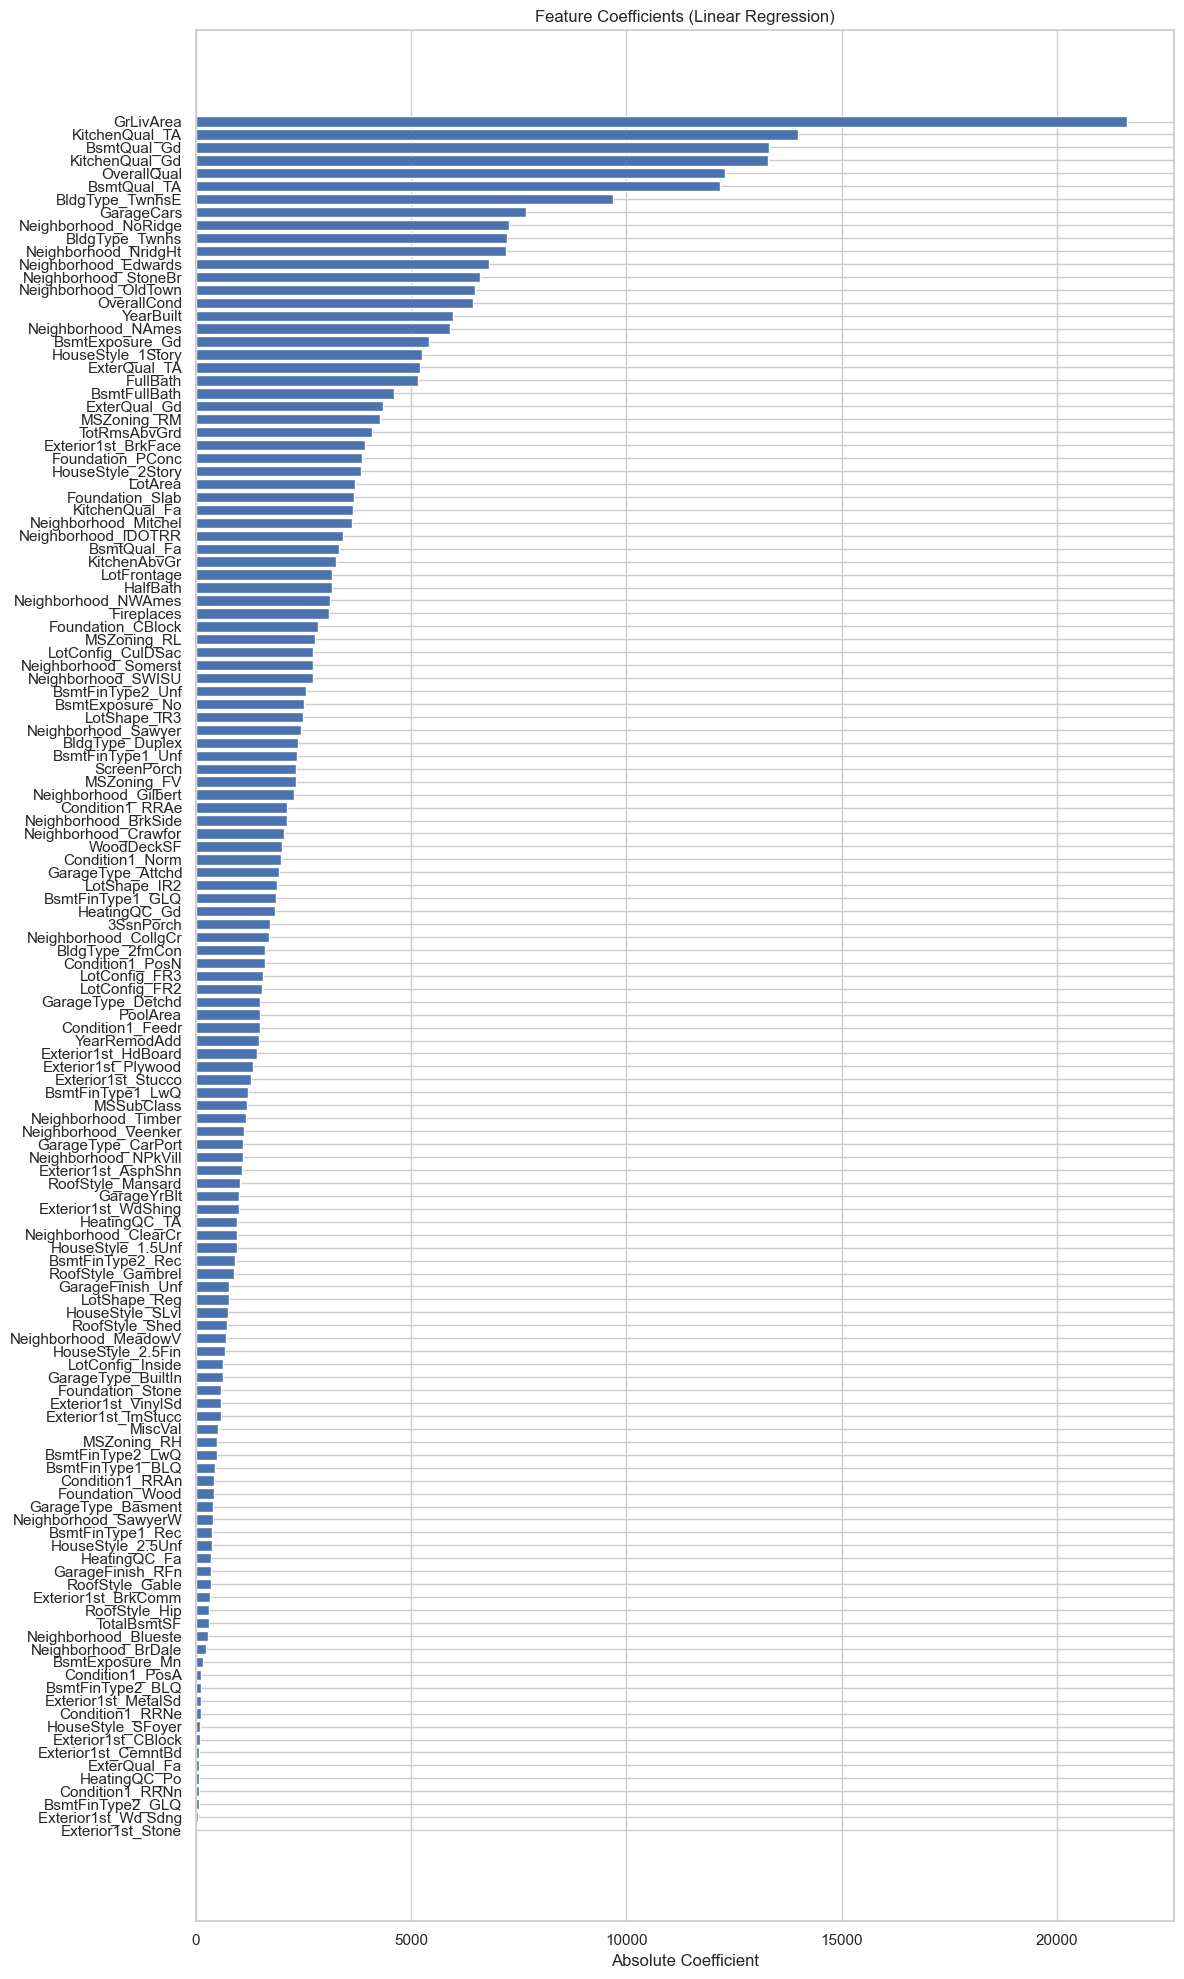

In [362]:
# 7. Tree-Based Feature Importance

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Pipeline: impute + scale + linear regression
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(X_encoded, y)

# Extract coefficients
model = pipe.named_steps["model"]
coefs = pd.Series(model.coef_, index=X_encoded.columns)

# Sort by absolute magnitude
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": np.abs(coefs)
}).sort_values(by="coefficient", ascending=False)

plt.figure(figsize=(12, max(6, len(coef_df) * 0.15)))

plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.gca().invert_yaxis()
plt.title("Feature Coefficients (Linear Regression)")
plt.xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()


In [363]:
# Select top 25 features by absolute coefficient
top_n = 25
top_features = coef_df.head(top_n)["feature"].tolist()

# Original feature names (before encoding)
original_features = X.columns.tolist()

# Map selected encoded features back to original columns
selected_original = set()

for feat in top_features:
    for col in original_features:
        if feat == col or feat.startswith(col + "_"):
            selected_original.add(col)

selected_original = list(selected_original)

print("Selected original features:")
print(selected_original)

# Keep only selected features + target
df = df[selected_original + ["SalePrice"]]

print("Final df shape:", df.shape)



Selected original features:
['OverallCond', 'OverallQual', 'GarageCars', 'TotRmsAbvGrd', 'ExterQual', 'KitchenQual', 'HouseStyle', 'BsmtFullBath', 'MSZoning', 'BldgType', 'Neighborhood', 'BsmtExposure', 'GrLivArea', 'FullBath', 'YearBuilt', 'BsmtQual']
Final df shape: (1168, 17)


**Final Columns and Descriptions**: 

**Target Variable**
- **SalePrice**: Final sale price of the house (target variable).

**Property Type & Zoning**
- **MSZoning**: General zoning classification of the property.  
- **BldgType**: Type of building structure (e.g., single-family, townhouse).  
- **HouseStyle**: Architectural style of the house.  

**Location & Neighborhood**
- **Neighborhood**: Physical neighborhood within Ames city limits.

**Overall Quality & Condition**
- **OverallQual**: Overall material and finish quality of the house.  
- **OverallCond**: Overall condition of the house.  

**Construction**
- **YearBuilt**: Original construction year of the property.  

**Exterior Features**
- **ExterQual**: Exterior material quality.  

**Basement Features**
- **BsmtQual**: Basement height/quality rating.  
- **BsmtExposure**: Walkout or garden-level exposure.  
- **BsmtFullBath**: Basement full bathrooms.  

**Living Area & Interior**
- **GrLivArea**: Total above-ground living area.  
- **FullBath**: Full bathrooms above grade.  
- **TotRmsAbvGrd**: Total rooms above grade (excluding bathrooms).  
- **KitchenQual**: Kitchen quality rating.  

**Garage Features**
- **GarageCars**: Garage capacity (number of cars).  

These 16 explanatory variables, together with **SalePrice**, form the final reduced dataset of 17 features used for modeling and further analysis.


#### 2.2 Handling Missing Values

In [364]:
df.isna().sum()

OverallCond      0
OverallQual      0
GarageCars       0
TotRmsAbvGrd     0
ExterQual        0
KitchenQual      0
HouseStyle       0
BsmtFullBath     0
MSZoning         0
BldgType         0
Neighborhood     0
BsmtExposure    28
GrLivArea        0
FullBath         0
YearBuilt        0
BsmtQual        28
SalePrice        0
dtype: int64

In [365]:
# According to the dataset documentation, NaN indicates properties with no basement.

# Replace missing values with 'NB' (No Basement).
df["BsmtExposure"] = df["BsmtExposure"].fillna("NB")
df["BsmtQual"] = df["BsmtQual"].fillna("NB")

# Confirm no remaining missing values
df.isna().sum()

OverallCond     0
OverallQual     0
GarageCars      0
TotRmsAbvGrd    0
ExterQual       0
KitchenQual     0
HouseStyle      0
BsmtFullBath    0
MSZoning        0
BldgType        0
Neighborhood    0
BsmtExposure    0
GrLivArea       0
FullBath        0
YearBuilt       0
BsmtQual        0
SalePrice       0
dtype: int64

#### 2.3 Correcting Data Types

In [366]:
df.dtypes

OverallCond      int64
OverallQual      int64
GarageCars       int64
TotRmsAbvGrd     int64
ExterQual       object
KitchenQual     object
HouseStyle      object
BsmtFullBath     int64
MSZoning        object
BldgType        object
Neighborhood    object
BsmtExposure    object
GrLivArea        int64
FullBath         int64
YearBuilt        int64
BsmtQual        object
SalePrice        int64
dtype: object

In [367]:
def describe_column(df, column_name):
    print(f"Column: {column_name}")
    print(f"Data type: {df[column_name].dtype}")
    print(f"Number of unique values: {df[column_name].nunique()}")
    print("\nHead (first 5 values):")
    print(df[column_name].head())
    print("\nTail (last 5 values):")
    print(df[column_name].tail())
    print("-----------------------\n")

for col in df.columns:
    describe_column(df, col)

Column: OverallCond
Data type: int64
Number of unique values: 9

Head (first 5 values):
0    6
1    7
2    7
3    7
4    6
Name: OverallCond, dtype: int64

Tail (last 5 values):
1163    5
1164    3
1165    7
1166    8
1167    5
Name: OverallCond, dtype: int64
-----------------------

Column: OverallQual
Data type: int64
Number of unique values: 10

Head (first 5 values):
0    5
1    6
2    5
3    5
4    5
Name: OverallQual, dtype: int64

Tail (last 5 values):
1163    6
1164    4
1165    5
1166    7
1167    7
Name: OverallQual, dtype: int64
-----------------------

Column: GarageCars
Data type: int64
Number of unique values: 5

Head (first 5 values):
0    1
1    2
2    0
3    1
4    1
Name: GarageCars, dtype: int64

Tail (last 5 values):
1163    2
1164    2
1165    2
1166    1
1167    3
Name: GarageCars, dtype: int64
-----------------------

Column: TotRmsAbvGrd
Data type: int64
Number of unique values: 12

Head (first 5 values):
0    5
1    7
2    4
3    7
4    6
Name: TotRmsAbvGrd, dt

In [368]:
# Ordinal + numeric columns (keep as int)
numeric_cols = [
    "OverallQual", "OverallCond",
    "GrLivArea", "GarageCars", "TotRmsAbvGrd",
    "BsmtFullBath", "FullBath",
    "YearBuilt", "SalePrice"
]

# Nominal categorical columns
categorical_cols = [
    "MSZoning", "BldgType", "HouseStyle", "Neighborhood",
    "ExterQual", "KitchenQual", "BsmtExposure", "BsmtQual"
]

df[numeric_cols] = df[numeric_cols].astype("int64")
df[categorical_cols] = df[categorical_cols].astype("category")

"""
Numeric (Continuous / Counts)
- GrLivArea
- GarageCars
- TotRmsAbvGrd
- BsmtFullBath
- FullBath
- YearBuilt
- SalePrice

Ordinal (Ordered Ratings: kept numeric)
- OverallQual
- OverallCond

Nominal (Categorical: no inherent order)
- MSZoning
- BldgType
- HouseStyle
- Neighborhood
- ExterQual
- KitchenQual
- BsmtExposure
- BsmtQual
"""

df.dtypes

OverallCond        int64
OverallQual        int64
GarageCars         int64
TotRmsAbvGrd       int64
ExterQual       category
KitchenQual     category
HouseStyle      category
BsmtFullBath       int64
MSZoning        category
BldgType        category
Neighborhood    category
BsmtExposure    category
GrLivArea          int64
FullBath           int64
YearBuilt          int64
BsmtQual        category
SalePrice          int64
dtype: object

#### 2.4 Handling Duplicate Values

In [369]:
df.duplicated().sum()
# No duplicates!

0

### 3. Outlier Detection and Target Variable Transformation

#### 3.1 Handling Categorical Variables

In [370]:
# Nominal categorical columns
categorical_cols = [
    "MSZoning", "BldgType", "HouseStyle", "Neighborhood",
    "ExterQual", "KitchenQual", "BsmtExposure", "BsmtQual"
]

# Ordinal columns
ordinal_cols = ["OverallQual", "OverallCond"]

# Nominal variables (sorted by frequency)
for col in categorical_cols:
    print(f"\nColumn: {col} (Nominal)")
    print(df[col].value_counts().sort_values(ascending=False))

# Ordinal variables (sorted by natural order)
for col in ordinal_cols:
    print(f"\nColumn: {col} (Ordinal)")
    print(df[col].value_counts().sort_index())



Column: MSZoning (Nominal)
MSZoning
RL         924
RM         172
FV          53
RH          15
C (all)      4
Name: count, dtype: int64

Column: BldgType (Nominal)
BldgType
1Fam      978
TwnhsE     88
Duplex     41
Twnhs      32
2fmCon     29
Name: count, dtype: int64

Column: HouseStyle (Nominal)
HouseStyle
1Story    577
2Story    360
1.5Fin    121
SLvl       52
SFoyer     28
1.5Unf     12
2.5Unf     11
2.5Fin      7
Name: count, dtype: int64

Column: Neighborhood (Nominal)
Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVill      7
Blueste      1
Name: count, dtype: int64

Column: ExterQual (Nominal)
ExterQual
TA    727
Gd    388
Ex     42
Fa     11
Name: count, dtype: int64

In [371]:
rare_categories = {
    "MSZoning": ["C (all)"],
    "Neighborhood": ["Blueste", "NPkVill", "Veenker"],
    "HouseStyle": ["2.5Fin"],
    "OverallCond": ["1", "2"],
    "OverallQual": ["1", "2"],
    "ExterQual": ["Fa"],
}

for col, rare_vals in rare_categories.items():
    df = df[~df[col].isin(rare_vals)]

print("New shape after removing rare categories:", df.shape)

New shape after removing rare categories: (1131, 17)


#### 3.2 Handling Numerical Variables

In [372]:
numeric_cols = [
    "GrLivArea",
    "GarageCars",
    "TotRmsAbvGrd",
    "BsmtFullBath",
    "FullBath",
    "YearBuilt",
]

k = 2.5  # conservative multiplier

initial_shape = df.shape[0]

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_whisker = q1 - k * iqr
    upper_whisker = q3 + k * iqr

    df = df[df[col].between(lower_whisker, upper_whisker)]

print("Rows before filtering:", initial_shape)
print("Rows after filtering:", df.shape[0])
print("Total rows removed:", initial_shape - df.shape[0])


Rows before filtering: 1131
Rows after filtering: 1126
Total rows removed: 5


#### 3.3 Handling Target Variable

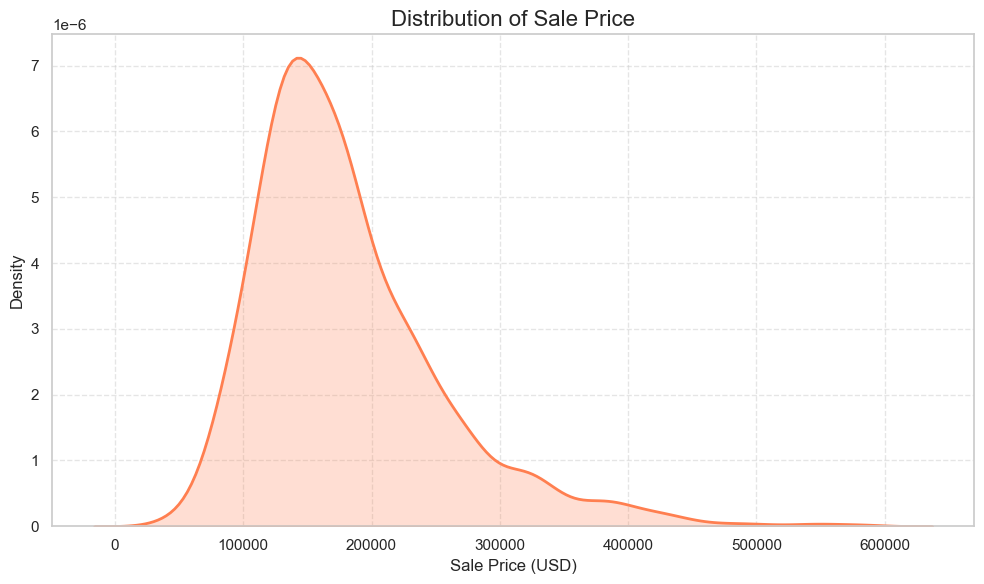

In [373]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df["SalePrice"], fill=True, color="coral", linewidth=2)

plt.title("Distribution of Sale Price", fontsize=16)
plt.xlabel("Sale Price (USD)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [374]:
print(df["SalePrice"].mean())
print(df["SalePrice"].median())
print(df["SalePrice"].skew())

180868.66873889876
165000.0
1.4541928413780363


##### Observations:

Based on the information above, we can draw several key insights:

1. **The mean is significantly higher than the median**, indicating right skewness. This is expected, as the mean is more sensitive to extreme values (outliers), while the median is more robust.
2. **The skewness value further supports this**, confirming that the distribution is indeed heavily skewed to the right.
3. **The KDE plot also reflects this skew**, showing a long stretch to the right.

##### Handling the Skewness:

To address this issue, we’ll apply two key techniques:

1. **Outlier Removal** using the IQR (Interquartile Range) method to eliminate extreme values.
2. **Log Transformation** using `log1p` to compress the scale and make the distribution more interpretable.

##### Why We Use `log1p(SalePrice)`:

Due to the skewed nature of the original `SalePrice`, we will model the **log-transformed** values instead, and this is mainly because the log will squish data points which will reduce the variance. This transformation improves the distribution’s shape, makes statistical analysis and visualizations more meaningful, and increases the likelihood of better model performance in later stages.

**Important:** After making predictions in the log-transformed space, we can simply reverse the transformation using `np.expm1()` to recover the actual trip duration.

In [375]:
# Removing outliers
target = "SalePrice"

k = 3  # conservative multiplier

initial_shape = df.shape[0]

q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3 - q1

lower_whisker = q1 - k * iqr
upper_whisker = q3 + k * iqr

df = df[df[target].between(lower_whisker, upper_whisker)]


Original skew: 1.1596134255828008
Log-transformed skew: 0.07200767172621517


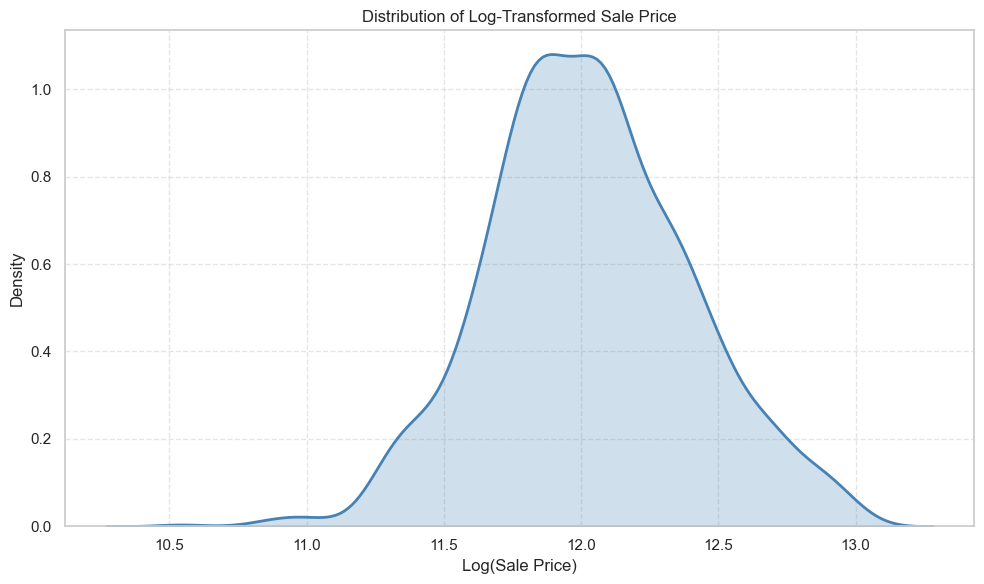

In [376]:
# Create log-transformed target
df["LogSalePrice"] = np.log1p(df["SalePrice"])

# Compare skewness
print("Original skew:", df["SalePrice"].skew())
print("Log-transformed skew:", df["LogSalePrice"].skew())

# Plot transformed distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(df["LogSalePrice"], fill=True, color="steelblue", linewidth=2)

plt.title("Distribution of Log-Transformed Sale Price")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Density")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

> We can clearly observe that applying the `log1p` transformation stabilizes the variance of the distribution and substantially reduces the right skewness. The transformed distribution appears much more symmetric, making it better suited for linear modeling assumptions.

In [377]:
# we can stick with the log version for the upcoming stages
df.drop("SalePrice", axis=1, inplace=True)

### 4. Categorical Feature Analysis

#### 4.1 Ordinal Features

There are two key ordinal features that we will examine in relation to the target variable. I will begin by analyzing the distribution of each feature individually, and then explore its relationship with the target variable to identify any potential patterns or associations.

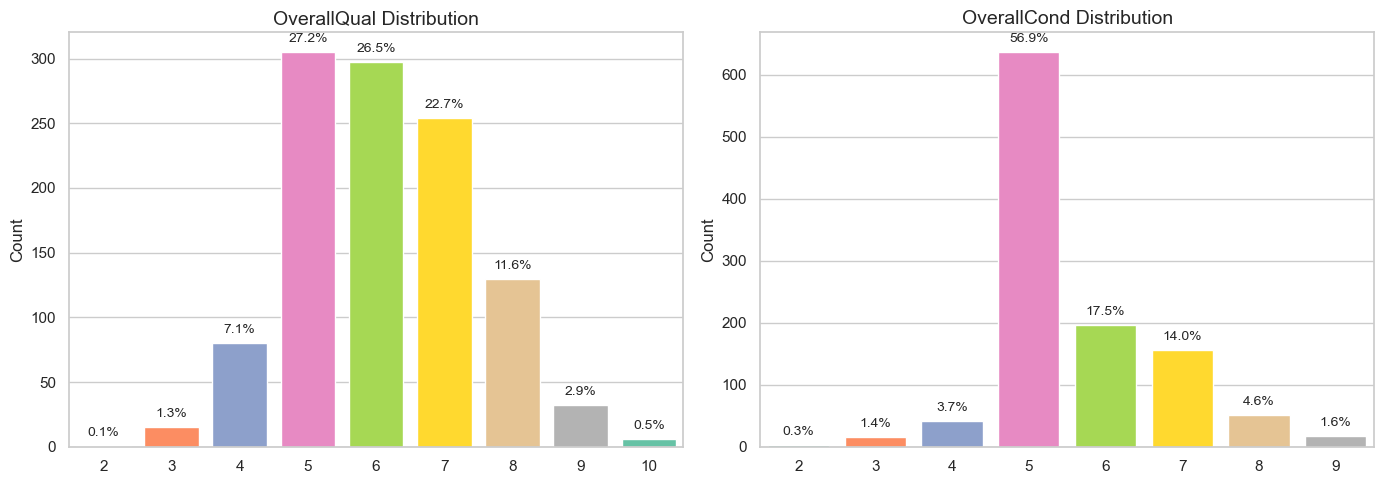

In [378]:
# Ordinal columns
cat_cols = ["OverallQual", "OverallCond"]

n = len(cat_cols)

fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
sns.set_theme(style="whitegrid")

# If only one column, make axes iterable
if n == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    counts = df[col].value_counts().sort_index()
    total = counts.sum()
    order = counts.index

    plot = sns.countplot(data=df, x=col, ax=ax, order=order)

    colors = sns.color_palette("Set2", len(order))
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)

    ax.set_title(f"{col} Distribution", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, ha="center", fontsize=11)

    for p in ax.patches:
        height = p.get_height()
        percent = f"{(height / total) * 100:.1f}%"
        ax.annotate(percent,
                    (p.get_x() + p.get_width() / 2., height),
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    xytext=(0, 5),
                    textcoords="offset points")

plt.tight_layout()
plt.show()


**Observations:**

* Both variables exhibit approximately bell-shaped distributions, with most observations concentrated around the middle rating levels.
* There appears to be a noticeable relationship between overall material quality and overall condition, suggesting that houses built with higher-quality materials tend to also be in better overall condition.
* In general, the distribution of `OverallQual` is slightly shifted toward higher values compared to `OverallCond`, indicating that material quality ratings tend to be somewhat stronger than condition ratings.
* The distribution pattern reflects typical housing market dynamics, where most properties fall within average to above-average categories, while houses with extremely high quality or condition are relatively rare.


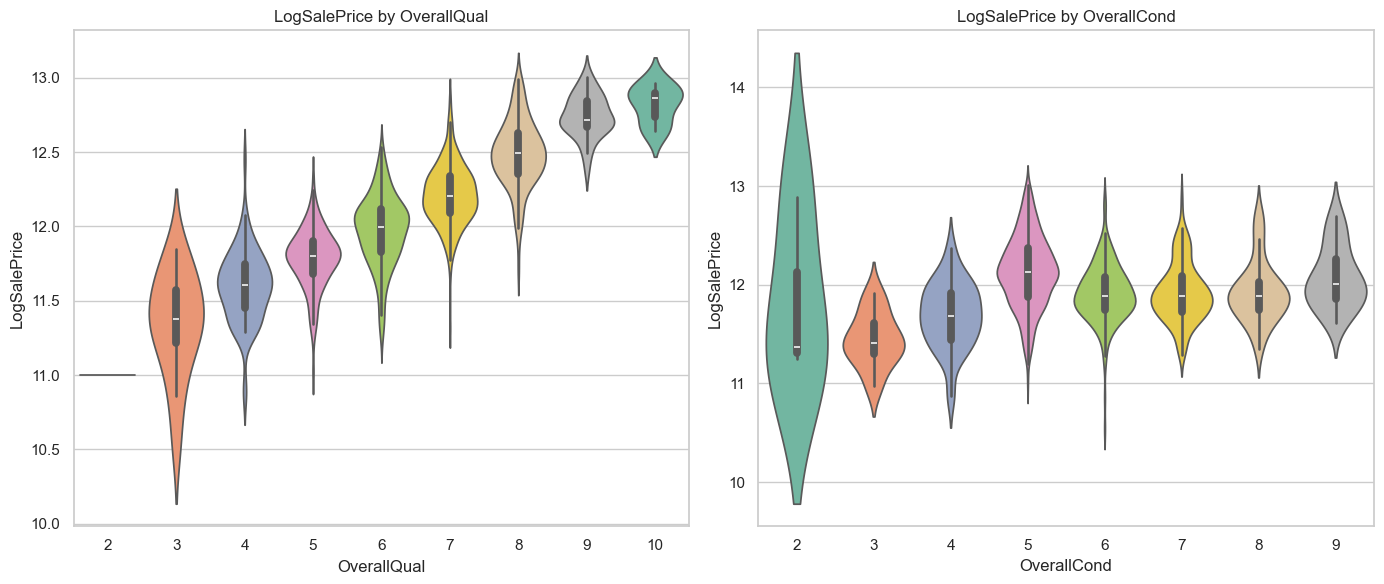

In [ ]:
target = "LogSalePrice"  

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 2, i)
    
    order = sorted(df[col].unique())
    
    sns.violinplot(
        x=col,
        y=target,
        data=df,
        order=order,
        palette="Set2"
    )
    
    plt.title(f"{target} by {col}")
    plt.xlabel(col)
    plt.ylabel(target)

plt.tight_layout()
plt.show()


**Observations: (Feature - Target Relationship)**

* There is a clear positive relationship between `OverallQual` and the sale price. As the overall material quality rating increases, the sale price rises noticeably, indicating a strong monotonic trend.
* In contrast, `OverallCond` does not appear to show a strong relationship with the sale price. The median price across different condition levels remains relatively similar, suggesting limited explanatory power.
* The distribution for `OverallCond = 2` appears highly right-skewed, likely due to a small number of high-priced observations. If the skewness were reduced or extreme values removed, the resulting violin plot would likely resemble the other condition levels, with a median closer to the overall pattern.

#### 4.2 Nominal Features

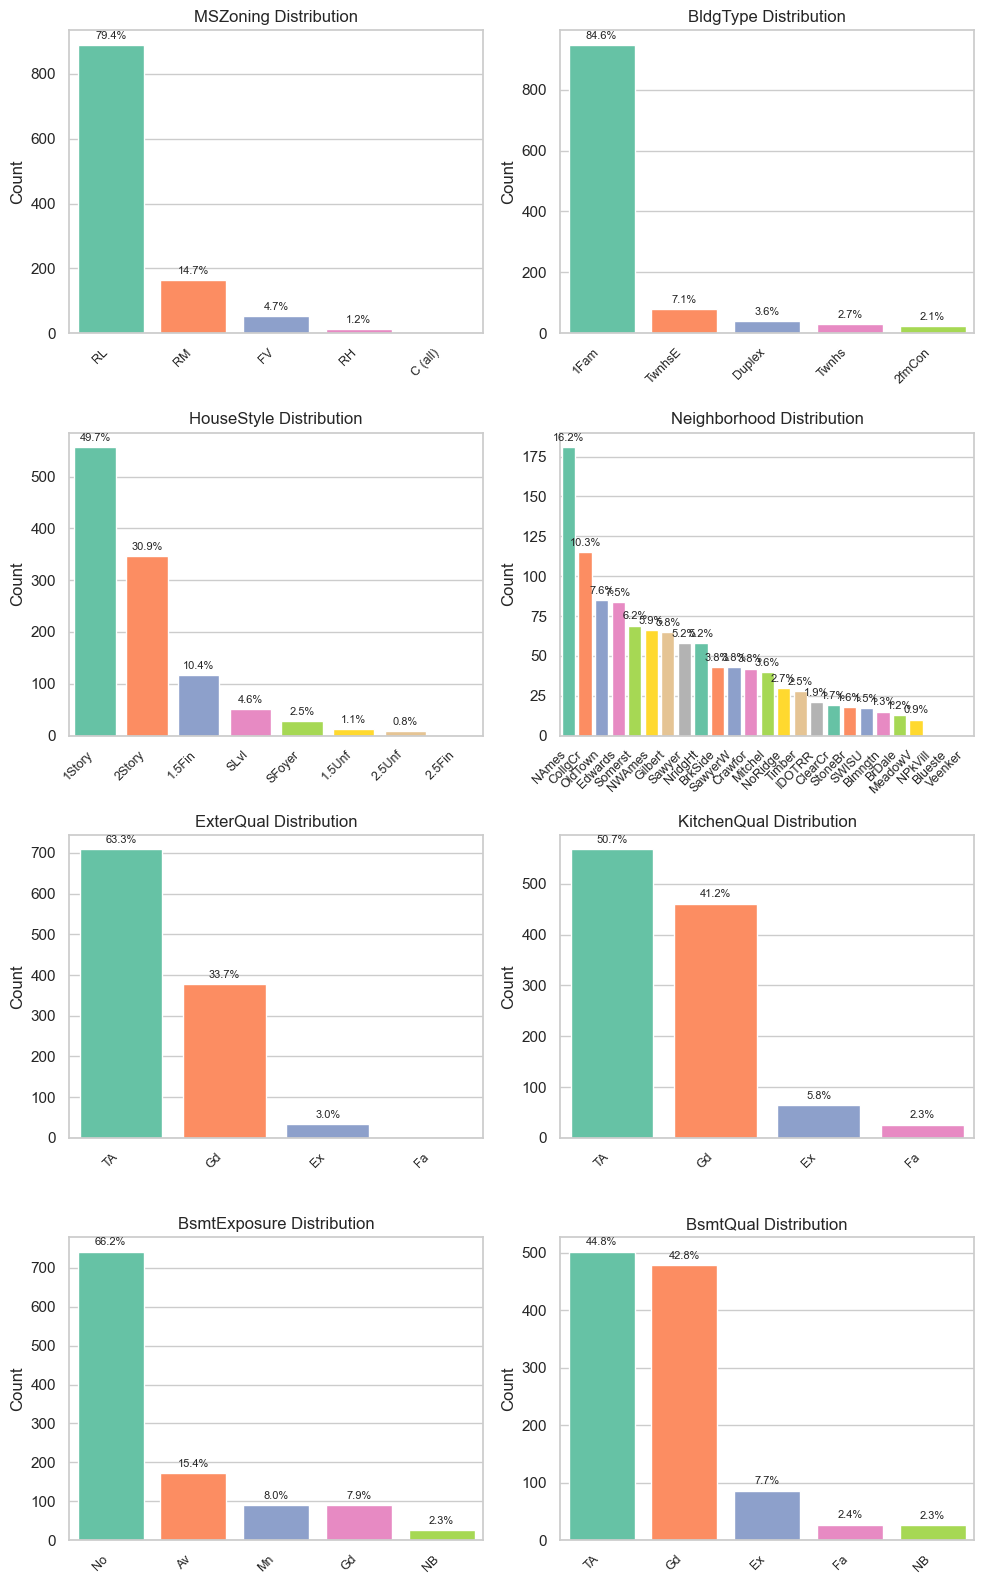

In [383]:
# Nominal categorical columns
cat_cols = [
    "MSZoning",
    "BldgType",
    "HouseStyle",
    "Neighborhood",
    "ExterQual",
    "KitchenQual",
    "BsmtExposure",
    "BsmtQual"
]

n = len(cat_cols)
n_cols = 2
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
sns.set_theme(style="whitegrid")

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    counts = df[col].value_counts()
    total = counts.sum()
    order = counts.index

    sns.countplot(data=df, x=col, ax=ax, order=order)

    colors = sns.color_palette("Set2", len(order))
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)

    ax.set_title(f"{col} Distribution", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_xticklabels(order, rotation=45, ha="right", fontsize=9)

    for p in ax.patches:
        height = p.get_height()
        percent = f"{(height / total) * 100:.1f}%"
        ax.annotate(
            percent,
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points"
        )

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Observations:**

* TODO 0 skip for now ...

#### Summary of Categorical Features

In ordinal:
- overall Quality seems to have strong relationship with the price
In nominal:

TODO;
in the dommain based analysis or the temporal - try to see how things differ from year to year and reflect that onn the design and whicch design is more expensive ... etc + try to see how designs changed and ...

### 5. Numerical Feature Analysis